In [109]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import sharpy.cases.templates.flying_wings as wings
import sharpy.sharpy_main
import sharpy.utils.plotutils as pu

In [110]:
speed = 25 #30.0
u_inf = speed #m/s
alpha_deg = 2
rho = 1.225

number_chordwise_panels = 8
number_spanwise_nodes = 16
wake_length_factor = 10

cases_folder = './cases/' # folder to store input files
output_folder = './output' # folder to save results
route_notebook_dir =  os.path.abspath('')

In [111]:
case_name = "Static_TipMass"
route_test_dir = os.path.abspath('')

length = 1.2
width = 0.1
height = 0.002
c_ref= 0.2
massperunit = 1.8
massweight = 0.1

pazy_altered = wings.PazyControlSurface(
    M = number_chordwise_panels,
    N = number_spanwise_nodes,
    Mstar_fact=10,
    u_inf=u_inf,
    alpha=alpha_deg,
    cs_deflection=[0,0],
    n_control_surfaces=2,
    rho=rho,
    tip_rod=True,
    b_ref=2.*length,
    main_chord=c_ref,
    pct_flap=0.2,
    aspect_ratio=2*length/c_ref,
    n_surfaces=2,
    physical_time=2,
    route = cases_folder + '/' + case_name,
    case_name=case_name,
    #physical_time = simulation_time,
)

In [112]:
def new_update_mass_stiff(self):
    import sharpy.utils.algebra as algebra

    #seeing our wing has roughly 2% of the area of the goland wing we have to scale the 
    #structural properties appropriately to achieve flutter, (as lift forces are proportional
    #to the wing area)
    E = 69e9  # Young's modulus in Pascals (Pa)
    G = 26e9  # Shear modulus in Pascals (Pa)
    rho = 2700

    # Cross-sectional properties
    A = width * height  # Area in m²
    Iy = (width * height**3) / 12  # Second moment of area about the y-axis (m⁴)
    Iz = (height * width**3) / 12  # Second moment of area about the z-axis (m⁴)
    print(Iy)
    print(Iz)
    J = 2*height**3*width/3  # Torsion constant approximation for rectangular section

    # Rigidity calculations
    EA = E * A
    GA = G * A
    GJ = G * J
    EIy = E * Iy
    EIz = E * Iz

    ea, ga = EA, GA
    gj = GJ
    eiy = EIy
    eiz = EIz
    base_stiffness = np.diag([ea, ga, ga, gj, eiy, eiz])
    self.stiffness = np.zeros((1, 6, 6))
    self.stiffness[0] = base_stiffness
    print(base_stiffness)
    
    m_unit = massperunit
    j_tors = (Iy+Iz)*rho
    print(Iy+Iz)
    print(j_tors)
    pos_cg_b = np.array([0., self.c_ref * (self.main_cg - self.main_ea), 0.])
    m_chi_cg = algebra.skew(m_unit * pos_cg_b)
    self.mass = np.zeros((1, 6, 6))
    self.mass[0, :, :] = np.diag([m_unit, m_unit, m_unit,
                                    j_tors, .1 * j_tors, .9 * j_tors])

    self.mass[0, :3, 3:] = m_chi_cg
    self.mass[0, 3:, :3] = -m_chi_cg

    self.elem_stiffness = np.zeros((self.num_elem_tot,), dtype=int)
    self.elem_mass = np.zeros((self.num_elem_tot,), dtype=int)

    n_lumped_mass = 2
    self.lumped_mass = np.zeros((n_lumped_mass))
    self.lumped_mass_position = np.zeros((n_lumped_mass, 3))
    self.lumped_mass_inertia = np.zeros((n_lumped_mass, 3, 3))
    self.lumped_mass_nodes = np.zeros((n_lumped_mass), dtype=int)

    #positive y is towards back
    self.lumped_mass[0] = massweight
    self.lumped_mass_position[0] = np.array([0, 0.05, 0])
    self.lumped_mass_nodes[0] = self.N//2
    self.lumped_mass_inertia[0, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.lumped_mass[1] = massweight
    self.lumped_mass_position[1] = np.array([0, 0.05, 0])
    self.lumped_mass_nodes[1] = self.N//2+1
    self.lumped_mass_inertia[1, :, :] = np.diag([1.2815E-04, 2.87E-07, 1.17E-04])

    self.main_ea = 0.33
    self.main_cg = 0.43

pazy_altered.update_mass_stiff = new_update_mass_stiff.__get__(pazy_altered, wings.PazyControlSurface) 

In [113]:
pazy_altered.clean_test_files()
pazy_altered.update_derived_params()
pazy_altered.set_default_config_dict()

pazy_altered.generate_aero_file()
pazy_altered.generate_fem_file()

6.666666666666668e-11
1.666666666666667e-07
[[1.38000000e+07 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 5.20000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.20000000e+06 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 1.38666667e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 4.60000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.15000000e+04]]
1.6673333333333336e-07
0.00045018000000000006


In [114]:
rom_settings = dict()
rom_settings['algorithm'] = 'mimo_rational_arnoldi'  # reduction algorithm
rom_settings['r'] = 6  # Krylov subspace order
frequency_continuous_k = np.array([0.])  # Interpolation point in the complex plane with reduced frequency units
frequency_continuous_w = 2 * u_inf * frequency_continuous_k / c_ref
rom_settings['frequency'] = frequency_continuous_w

pazy_altered.config['SHARPy'] = {
    'flow':
        ['BeamLoader', 'AerogridLoader',
         'StaticCoupled',
         'AerogridPlot',
         'BeamPlot',
         'Modal',
         'LinearAssembler',
         'AsymptoticStability',
         ],
    'case': pazy_altered.case_name, 'route': pazy_altered.route,
    'write_screen': 'on', 'write_log': 'on',    # Change to 'on' as neded.
    'log_folder': route_test_dir + '/output/',
    'log_file': pazy_altered.case_name + '.log'
}

pazy_altered.config['BeamLoader'] = {
    'unsteady': 'off',
    'orientation': pazy_altered.quat}

pazy_altered.config['AerogridLoader'] = {
    'unsteady': 'off',
    'aligned_grid': 'on',
    'mstar': pazy_altered.Mstar_fact * pazy_altered.M,
    'freestream_dir': pazy_altered.u_inf_direction,
    'wake_shape_generator': 'StraightWake',
    'wake_shape_generator_input': {'u_inf': pazy_altered.u_inf,
                                    'u_inf_direction': pazy_altered.u_inf_direction,
                                    'dt': pazy_altered.dt}}

pazy_altered.config['StaticCoupled'] = {
    'print_info': 'on',
    'max_iter': 200,
    'n_load_steps': 1,
    'tolerance': 1e-10,
    'relaxation_factor': 0.,
    'aero_solver': 'StaticUvlm',
    'aero_solver_settings': {
        'rho': pazy_altered.rho,
        'print_info': 'off',
        'horseshoe': 'off',
        'num_cores': 4,
        'n_rollup': 0,
        'rollup_dt': pazy_altered.dt,
        'rollup_aic_refresh': 1,
        'rollup_tolerance': 1e-4,
        'velocity_field_generator': 'SteadyVelocityField',
        'velocity_field_input': {
            'u_inf': pazy_altered.u_inf,
            'u_inf_direction': pazy_altered.u_inf_direction}},
    'structural_solver': 'NonLinearStatic',
    'structural_solver_settings': {'print_info': 'off',
                                   'max_iterations': 150,
                                   'num_load_steps': 4,
                                   'delta_curved': 1e-1,
                                   'min_delta': 1e-10,
                                   'gravity_on': 'on',
                                   'gravity': 9.81}}

pazy_altered.config['AerogridPlot'] = {'include_rbm': 'off',
                             'include_applied_forces': 'on',
                             'minus_m_star': 0}

pazy_altered.config['BeamPlot'] = {'include_rbm': 'off',
                         'include_applied_forces': 'on'}

pazy_altered.config['Modal'] = {'NumLambda': 20,
                      'rigid_body_modes': 'off',
                      'print_matrices': 'on', # 'keep_linear_matrices': 'on',            'write_dat': 'off',
                      'rigid_modes_cg': 'off',
                      'continuous_eigenvalues': 'off',
                      'dt': 0,
                      'plot_eigenvalues': False,
                      'max_rotation_deg': 15.,
                      'max_displacement': 0.15,
                      'write_modes_vtk': True,
                      'use_undamped_modes': True}

pazy_altered.config['LinearAssembler'] = {'linear_system': 'LinearAeroelastic',
                                'linear_system_settings': {
                                    'beam_settings': {'modal_projection': 'on',
                                                      'inout_coords': 'modes',
                                                      'discrete_time': 'on',
                                                      'newmark_damp': 0.5e-4,
                                                      'discr_method': 'newmark',
                                                      'dt': pazy_altered.dt,
                                                      'proj_modes': 'undamped',
                                                      'use_euler': 'off',
                                                      'num_modes': 20,
                                                      'print_info': 'on',
                                                      'gravity': 'on',
                                                      'remove_sym_modes': 'on',
                                                      'remove_dofs': []},
                                    'aero_settings': {'dt': pazy_altered.dt,
                                                      'ScalingDict': {'length': 0.5 * pazy_altered.c_ref,
                                                                      'speed': u_inf,
                                                                      'density': rho},
                                                      'integr_order': 2,
                                                      'density': pazy_altered.rho,
                                                      'remove_predictor': 'on',
                                                      'use_sparse': 'on',
                                                      'remove_inputs': ['u_gust'],
                                                      'rom_method': ['Krylov'],
                                                      'rom_method_settings': {'Krylov': rom_settings}},
                                    }}

pazy_altered.config['AsymptoticStability'] = {'print_info': True,
                                    'velocity_analysis': [10, 40, 81],
                                   'modes_to_plot': []}
                                    

pazy_altered.config.write()

In [115]:
sharpy_output = sharpy.sharpy_main.main(['', pazy_altered.route + pazy_altered.case_name + '.sharpy'])

--------------------------------------------------------------------------------
            ######  ##     ##    ###    ########  ########  ##    ##
           ##    ## ##     ##   ## ##   ##     ## ##     ##  ##  ##
           ##       ##     ##  ##   ##  ##     ## ##     ##   ####
            ######  ######### ##     ## ########  ########     ##
                 ## ##     ## ######### ##   ##   ##           ##
           ##    ## ##     ## ##     ## ##    ##  ##           ##
            ######  ##     ## ##     ## ##     ## ##           ##
--------------------------------------------------------------------------------
Aeroelastics Lab, Aeronautics Department.
    Copyright (c), Imperial College London.
    All rights reserved.
    License available at https://github.com/imperialcollegelondon/sharpy
Running SHARPy from /home/password/sharpy/sharpy
SHARPy being run is in /home/password/.local/lib/python3.10/site-packages
SHARPy output folder set
	/home/password/sharpy/sharpy/output//

fatal: not a git repository (or any of the parent directories): .git


|  1  |  0  |  -2.74299  |  0.5902  | -0.0006  | -9.8047  |  0.0014  |  0.4065  |  0.0001  |
|  2  |  0  |  -3.10284  |  0.5303  | -0.0008  | -8.3039  |  0.0013  |  0.4503  |  0.0001  |
|  3  |  0  |  -3.42815  |  0.4999  | -0.0007  | -7.5573  |  0.0011  |  0.4719  |  0.0001  |
|  4  |  0  |  -3.75023  |  0.4848  | -0.0006  | -7.1909  |  0.0009  |  0.4824  |  0.0001  |
|  5  |  0  |  -4.06967  |  0.4774  | -0.0005  | -7.0126  |  0.0008  |  0.4875  |  0.0001  |
|  6  |  0  |  -4.38766  |  0.4738  | -0.0005  | -6.9261  |  0.0007  |  0.4899  |  0.0000  |
|  7  |  0  |  -4.70489  |  0.4720  | -0.0005  | -6.8844  |  0.0007  |  0.4911  |  0.0000  |
|  8  |  0  |  -5.02176  |  0.4712  | -0.0004  | -6.8642  |  0.0007  |  0.4917  |  0.0000  |
|  9  |  0  |  -5.33843  |  0.4708  | -0.0004  | -6.8545  |  0.0006  |  0.4920  |  0.0000  |
| 10  |  0  |  -5.65502  |  0.4706  | -0.0004  | -6.8498  |  0.0006  |  0.4921  |  0.0000  |
| 11  |  0  |  -5.97157  |  0.4705  | -0.0004  | -6.8475  |  0.0006  |

/home/password/.local/lib/python3.10/site-packages/scipy/sparse/_index.py:151: SparseEfficiencyWarning:

Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.



	state-space model produced in form:
			h_{n+1} = A h_{n} + B u_{n}
			with:
	x_n = h_n + Bp u_n
			...done in 0.98 sec
Scaling UVLM system with reference time 0.004000s
Non-dimensional time step set (0.250000)
System scaled in 0.511674s
Generating an instance of LinearBeam
Variable remove_rigid_states has no assigned value in the settings file.
    will default to the value: False
Warning, projecting system with damping onto undamped modes


/home/password/.local/lib/python3.10/site-packages/sharpy/linear/src/lingebm.py:313: UserWarning:

Euler parametrisation not implemented - Either rigid body modes are not being used or this method has already been called.




Linearising gravity terms...
	M = 0.00 kg
	X_CG A -> -1.56 0.99 0.00
Node  1 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.150 -0.006
			-> G 0.000 0.150 -0.006
	Node mass:
		Matrix: 0.2880
Node  2 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.299 -0.022
			-> G -0.000 0.299 -0.022
	Node mass:
		Matrix: 0.1440
Node  3 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.447 -0.047
			-> G -0.001 0.447 -0.047
	Node mass:
		Matrix: 0.2880
Node  4 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.593 -0.079
			-> G -0.003 0.593 -0.079
	Node mass:
		Matrix: 0.1440
Node  5 	-> B -0.000 -0.000 0.000
			-> A 0.000 0.739 -0.115
			-> G -0.004 0.739 -0.115
	Node mass:
		Matrix: 0.2880
Node  6 	-> B -0.000 -0.000 0.000
			-> A -0.000 0.884 -0.155
			-> G -0.006 0.884 -0.155
	Node mass:
		Matrix: 0.1440
Node  7 	-> B -0.000 -0.000 0.000
			-> A -0.000 1.028 -0.197
			-> G -0.007 1.028 -0.197
	Node mass:
		Matrix: 0.2880
Node  8 	-> B 0.001 0.018 -0.004
			-> A -0.019 1.171 -0.244
			-> G -0.028 1.171 -0.243
	Node mass:
		

/home/password/.local/lib/python3.10/site-packages/sharpy/rom/krylov.py:242: UserWarning:

Reduced Order Model Unstable



LTI	u: 10.00 m/2	max. CT eig. real: 18.064196	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	93.29	93.29
Updating C and K matrices and natural frequencies with new normalised time...
LTI	u: 10.38 m/2	max. CT eig. real: 18.741700	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	96.79	96.79
Updating C and K matrices and natural frequencies with new normalised time...
LTI	u: 10.75 m/2	max. CT eig. real: 19.419259	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	100.28	100.28
Updating C and K matrices and natural frequencies with new normalised time...
LTI	u: 11.12 m/2	max. CT eig. real: 20.096877	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	103.78	103.78
Updating C and K matrices and natural frequencies with new normalised time...
LTI	u: 11.50 m/2	max. CT eig. real: 20.774555	
	N unstab.: 002
	Unstable aeroelastic natural frequency CT(rad/s):	107.28	107.28
Updating C and K matrices and natural frequencies wi

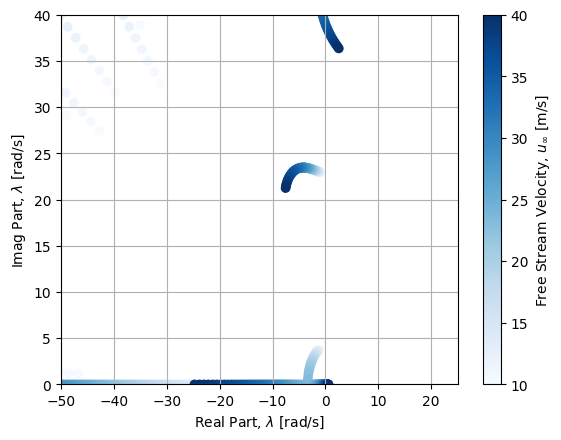

In [116]:
file_name = './output/%s/stability/velocity_analysis_min0100_max0400_nvel0081.dat' % case_name
%matplotlib inline
velocity_analysis = np.loadtxt(file_name)
u_inf = velocity_analysis[:, 0]
eigs_r = velocity_analysis[:, 1]
eigs_i = velocity_analysis[:, 2]

fig = plt.figure()
plt.scatter(eigs_r, eigs_i, c=u_inf, cmap='Blues')
cbar = plt.colorbar()
cbar.set_label('Free Stream Velocity, $u_\infty$ [m/s]')

plt.grid()
plt.xlim(-50, 25)
plt.ylim(0, 40)
plt.xlabel('Real Part, $\lambda$ [rad/s]')
plt.ylabel('Imag Part, $\lambda$ [rad/s]');

[ 0.19363995  0.19363995 -0.29996048 ... -0.62784899 -0.58082552 -0.47879044]


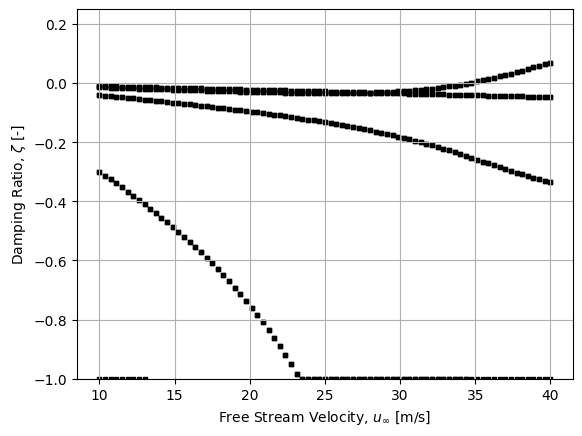

In [117]:
fig = plt.figure()
natural_frequency = np.sqrt(eigs_r ** 2 + eigs_i ** 2)
damping_ratio = eigs_r / natural_frequency
cond = (eigs_r>-25) * (eigs_r<10) * (natural_frequency<100) # filter unwanted eigenvalues for this plot (mostly aero modes)
print(damping_ratio)
plt.scatter(u_inf[cond], damping_ratio[cond], color='k', marker='s', s=9)

plt.grid()
plt.ylim(-1, 0.25)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Damping Ratio, $\zeta$ [-]');

[9.32875496e+01 9.32875496e+01 3.95305796e+00 ... 6.45807670e+03 6.17490766e+03 5.72545955e+03]


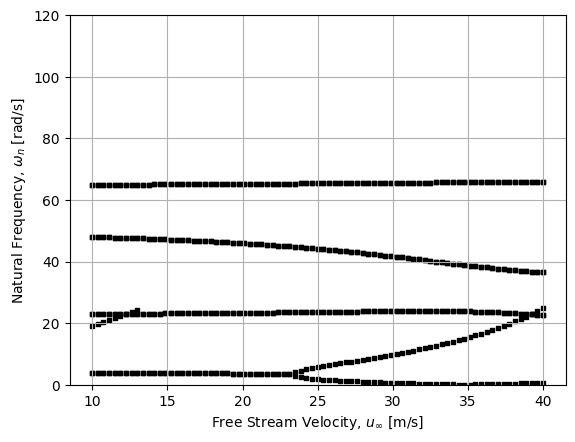

In [118]:
fig = plt.figure()
cond = (eigs_r>-25) * (eigs_r<10) # filter unwanted eigenvalues for this plot (mostly aero modes)
plt.scatter(u_inf[cond], natural_frequency[cond], color='k', marker='s', s=9)
print(natural_frequency)
plt.grid()
plt.ylim(0, 120)
plt.xlabel('Free Stream Velocity, $u_\infty$ [m/s]')
plt.ylabel('Natural Frequency, $\omega_n$ [rad/s]');

6.666666666666668e-11
16.79203526574231


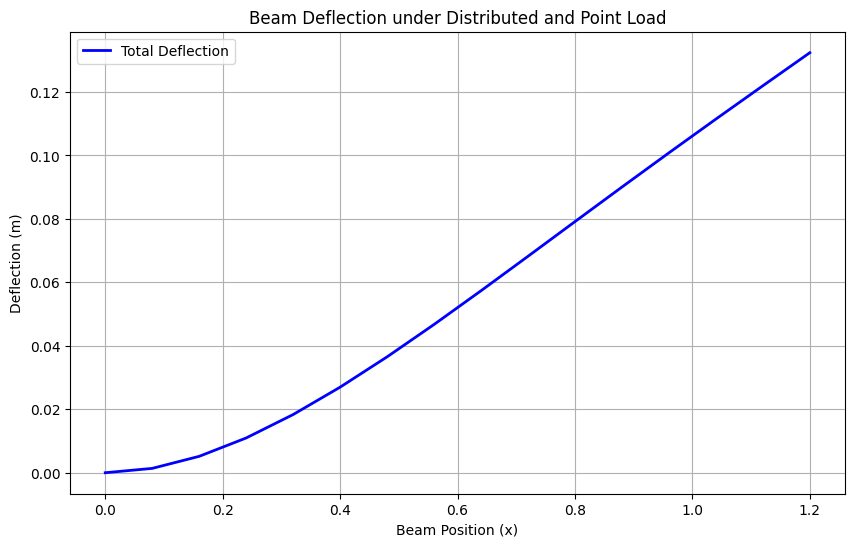

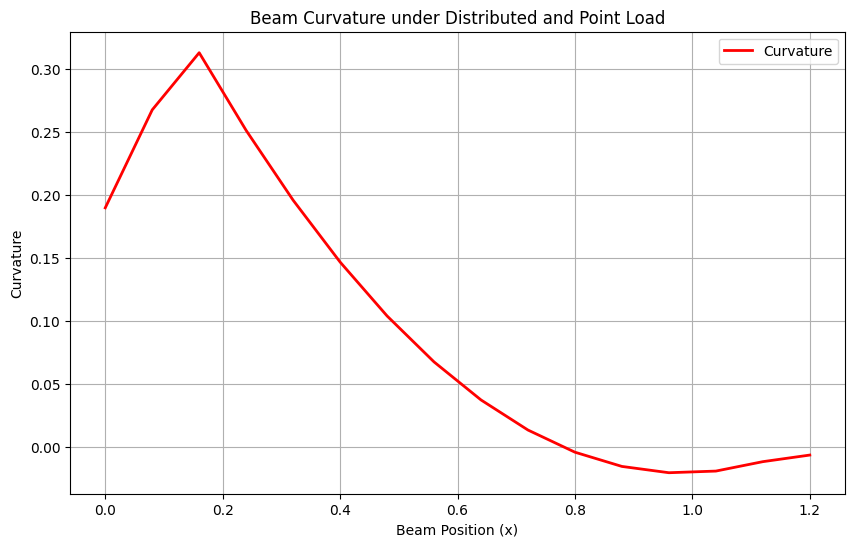

In [119]:
import numpy as np

# Constants
rho = 1.225  # air density (kg/m^3) at atmospheric conditions
V = speed # velocity (m/s)
chord = c_ref  # chord length (m)
span = length  # span (m)
E = 69e9  # Young's modulus for aluminum (Pa)
I = (width * height**3) / 12  # moment of inertia (m^4)
print(I)
CL = alpha_deg*np.pi  # Adjusted lift coefficient for NACA 0012 at 2 degrees AoA
aoa = np.radians(2)  # angle of attack in radians

# Aerodynamic forces
q = 0.5 * rho * V**2  # dynamic pressure (Pa)
L_per_span = q * CL * aoa * chord  # lift per unit span (N/m)
print(L_per_span)

# Tip mass properties
m_tip = massweight  # kg, point mass at the tip
g = 9.81  # gravity (m/s^2)
F_tip = m_tip * g  # force due to the point mass (N)

# Beam deflection
x = np.linspace(0,span,number_spanwise_nodes)
deflection = (((L_per_span - 9.81*1.25) * x**2) / (24 * E * I)) * (x**2 + 6 * span**2 - 4 * span * x)

# Additional deflection due to point load at the tip
deflection_tip = (F_tip * x**2) / (6 * E * I) * (3 * span - x)

# Total deflection
deflection_total = deflection - deflection_tip

# Plot deflection
plt.figure(figsize=(10, 6))
plt.plot(x, deflection_total, 'b-', linewidth=2, label='Total Deflection')
plt.title('Beam Deflection under Distributed and Point Load')
plt.xlabel('Beam Position (x)')
plt.ylabel('Deflection (m)')
plt.grid(True)
plt.legend()
plt.show()

# Curvature (second derivative of deflection)
d_deflection_dx = np.gradient(deflection_total, x)
d2_deflection_dx2 = np.gradient(d_deflection_dx, x)

plt.figure(figsize=(10, 6))
plt.plot(x, d2_deflection_dx2, 'r-', linewidth=2, label='Curvature')
plt.title('Beam Curvature under Distributed and Point Load')
plt.xlabel('Beam Position (x)')
plt.ylabel('Curvature')
plt.grid(True)
plt.legend()
plt.show()

In [120]:
wake_length = 50
chord = 0.2
num_chord_panels = number_chordwise_panels
WSP = 20
dt = chord/num_chord_panels/WSP
wake_panels = int(wake_length*chord/dt)
pu.plot_timestep(sharpy_output, tstep=-1, minus_mstar=(wake_panels - 6), plotly=True, custom_scaling=False, z_compression=0.5).update_layout(scene=dict(aspectmode='data')).show()
